<a href="https://colab.research.google.com/github/neelagarwal4321/first-project/blob/neel_dev/Car_Price_Prediction_Using_Multiple_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
hellbuoy_car_price_prediction_path = kagglehub.dataset_download('hellbuoy/car-price-prediction')

print('Data source import complete.')


Using Colab cache for faster access to the 'car-price-prediction' dataset.
Data source import complete.


# Project : Car Price Prediction using Multiple Regression Models

## Goals
- Load and perform basic data exploration
- Perform Exploratory Data Analysis
- Perform Feature Analysis
- Model using multiple regression models
- Conclusion

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/car-price-prediction/CarPrice_Assignment.csv
/kaggle/input/car-price-prediction/Data Dictionary - carprices.xlsx


## Import Libraries

In [3]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Modeling
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Evaluation
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error

In [4]:
# Load the dataset
df = pd.read_csv("/kaggle/input/car-price-prediction/CarPrice_Assignment.csv")

In [5]:
# First Few Rows
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## Basic Data Exploration

In [6]:
# Checking for dataset shape
df.shape

(205, 26)

There are 205 rows and 26 columns

In [7]:
# Basic summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [8]:
# Statistical Description
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [9]:
# Check for null values
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


The dataset is clean without any null values

In [10]:
# Dividing into numerical and categorical columns

numerical_cols = df.select_dtypes(exclude = 'object').columns.to_list()
categorical_cols = df.select_dtypes("object").columns.to_list()

# Print the cols
print("Numerical Columns :")
for col in numerical_cols:
    print(col, end = ",")
print("\n-----------------------------------")
print("Categorical Columns:")
for col in categorical_cols:
    print(col, end = ",")

Numerical Columns :
car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,
-----------------------------------
Categorical Columns:
CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem,

## EDA

### Univariate Analysis

#### Numerical Columns

In [11]:
num_cols = len(numerical_cols)
cols_per_row = 5
num_rows = int(np.ceil(num_cols / cols_per_row))

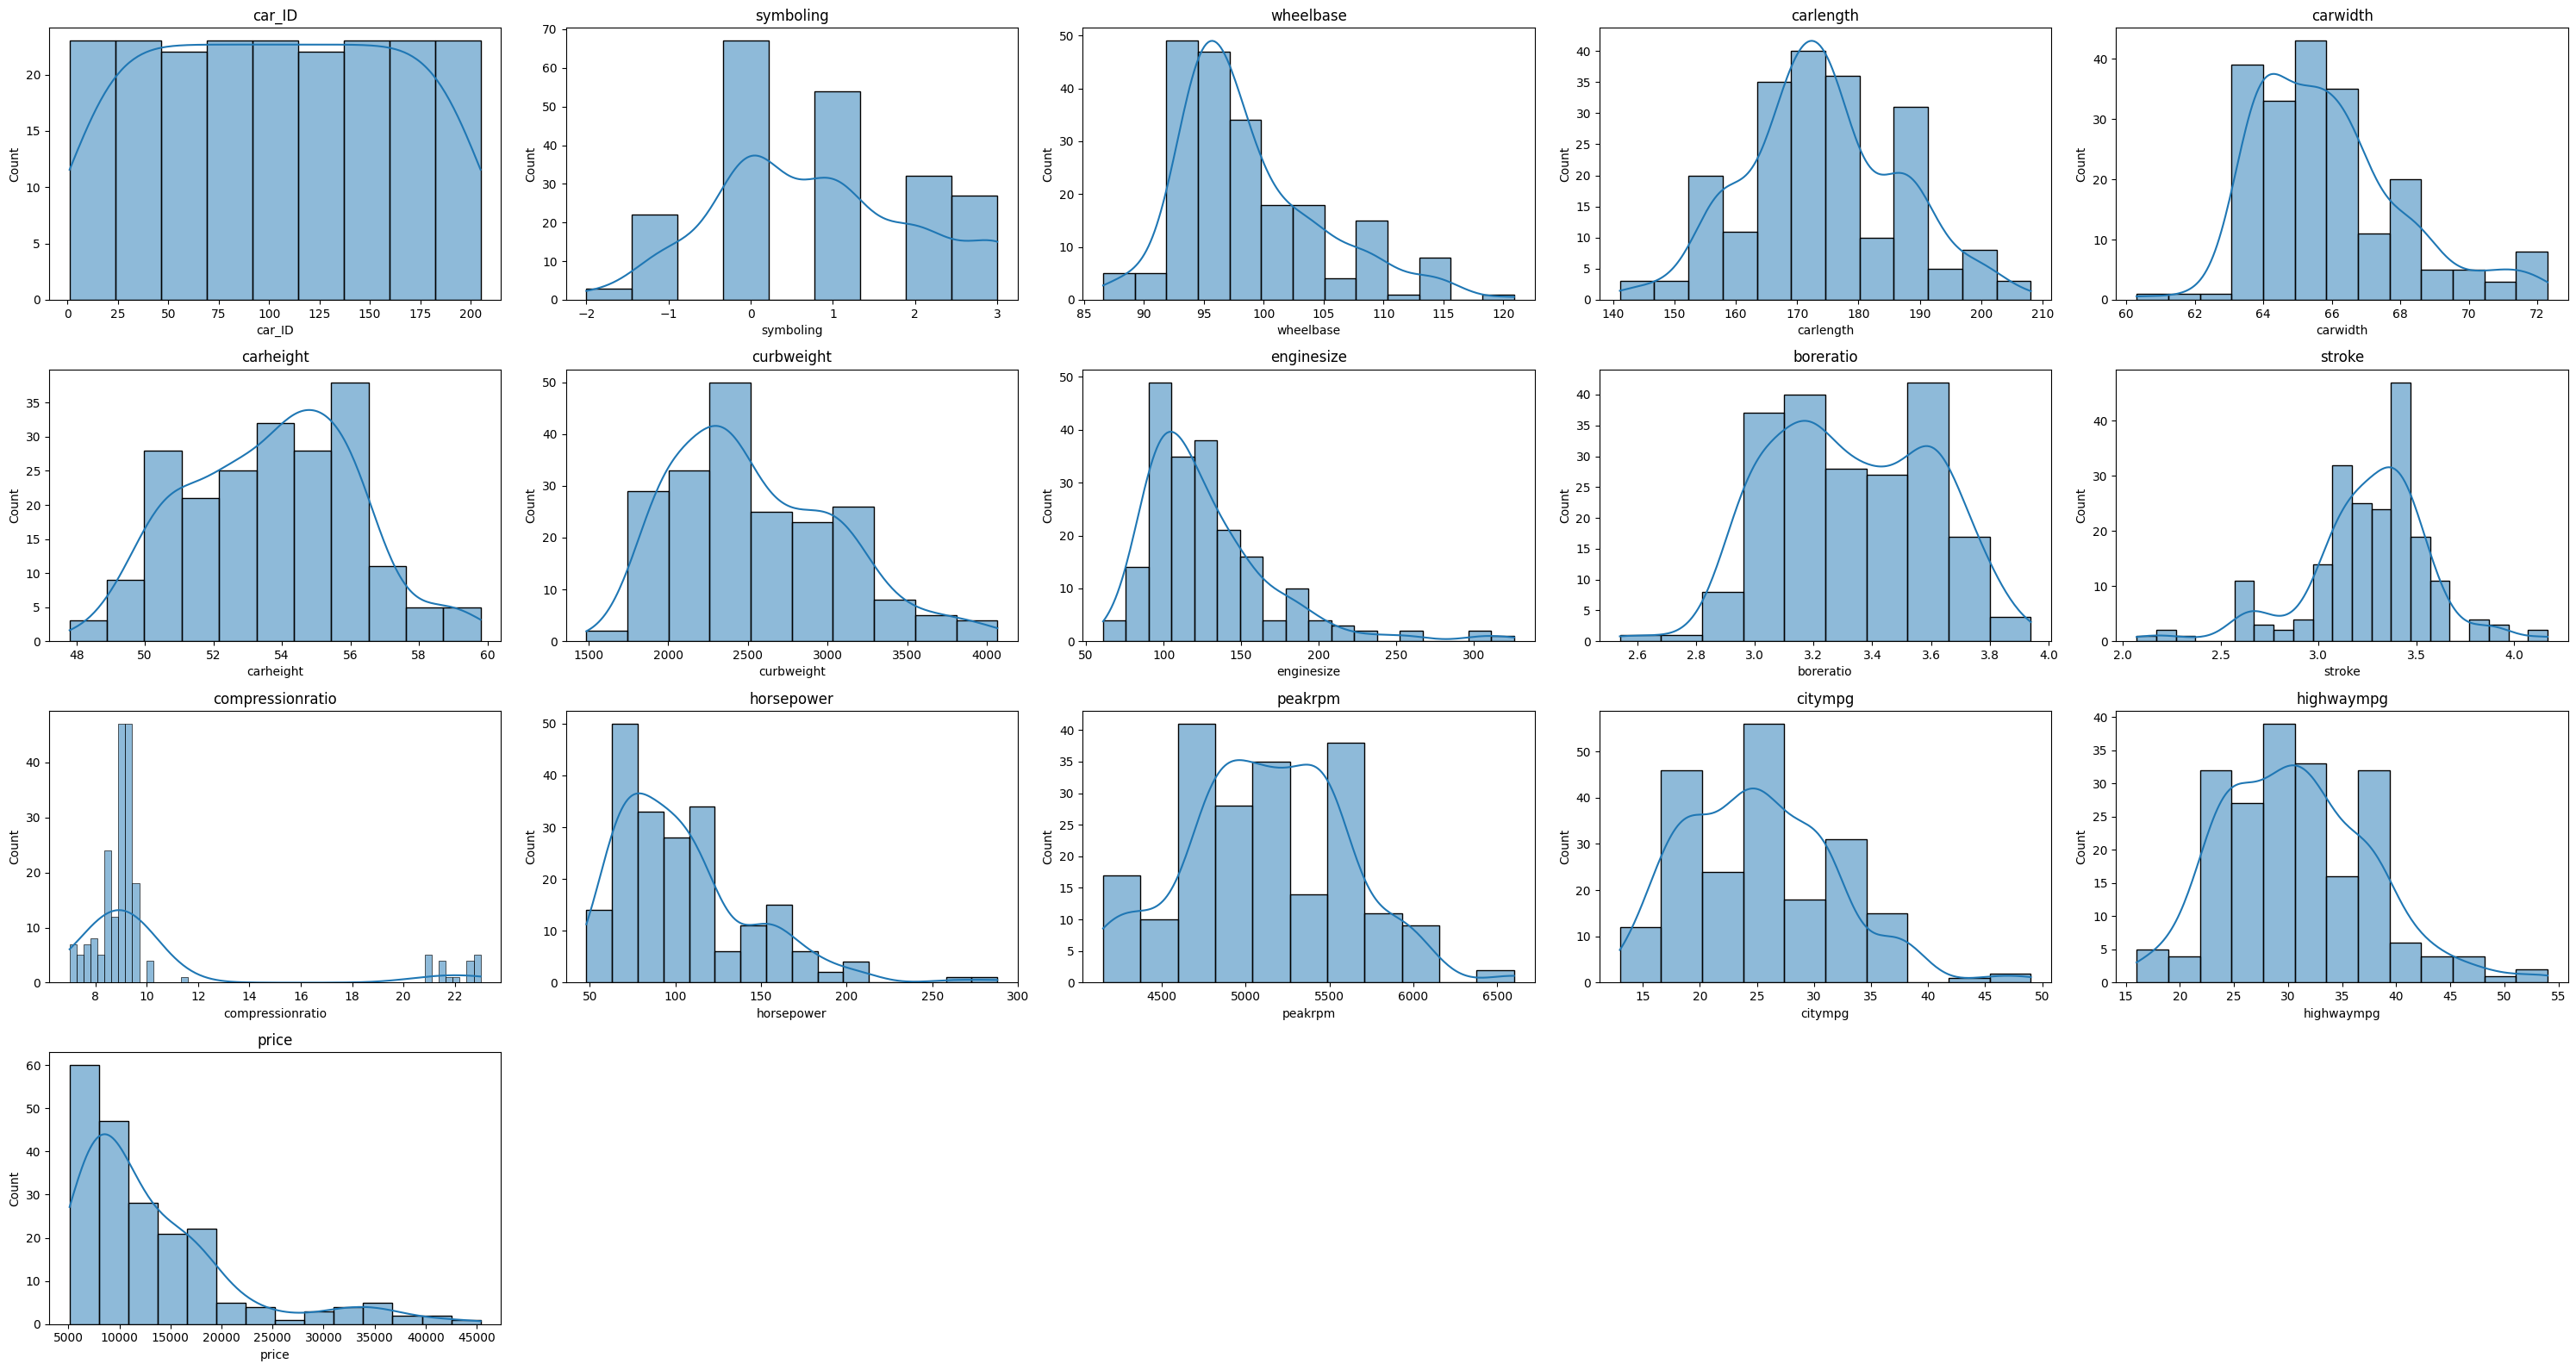

In [12]:
# Histogram
plt.figure(figsize=(cols_per_row * 6, num_rows * 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, cols_per_row, i + 1)
    sns.histplot(df[col], kde = True)
    plt.title(col, fontsize=12)

plt.tight_layout()
plt.show()

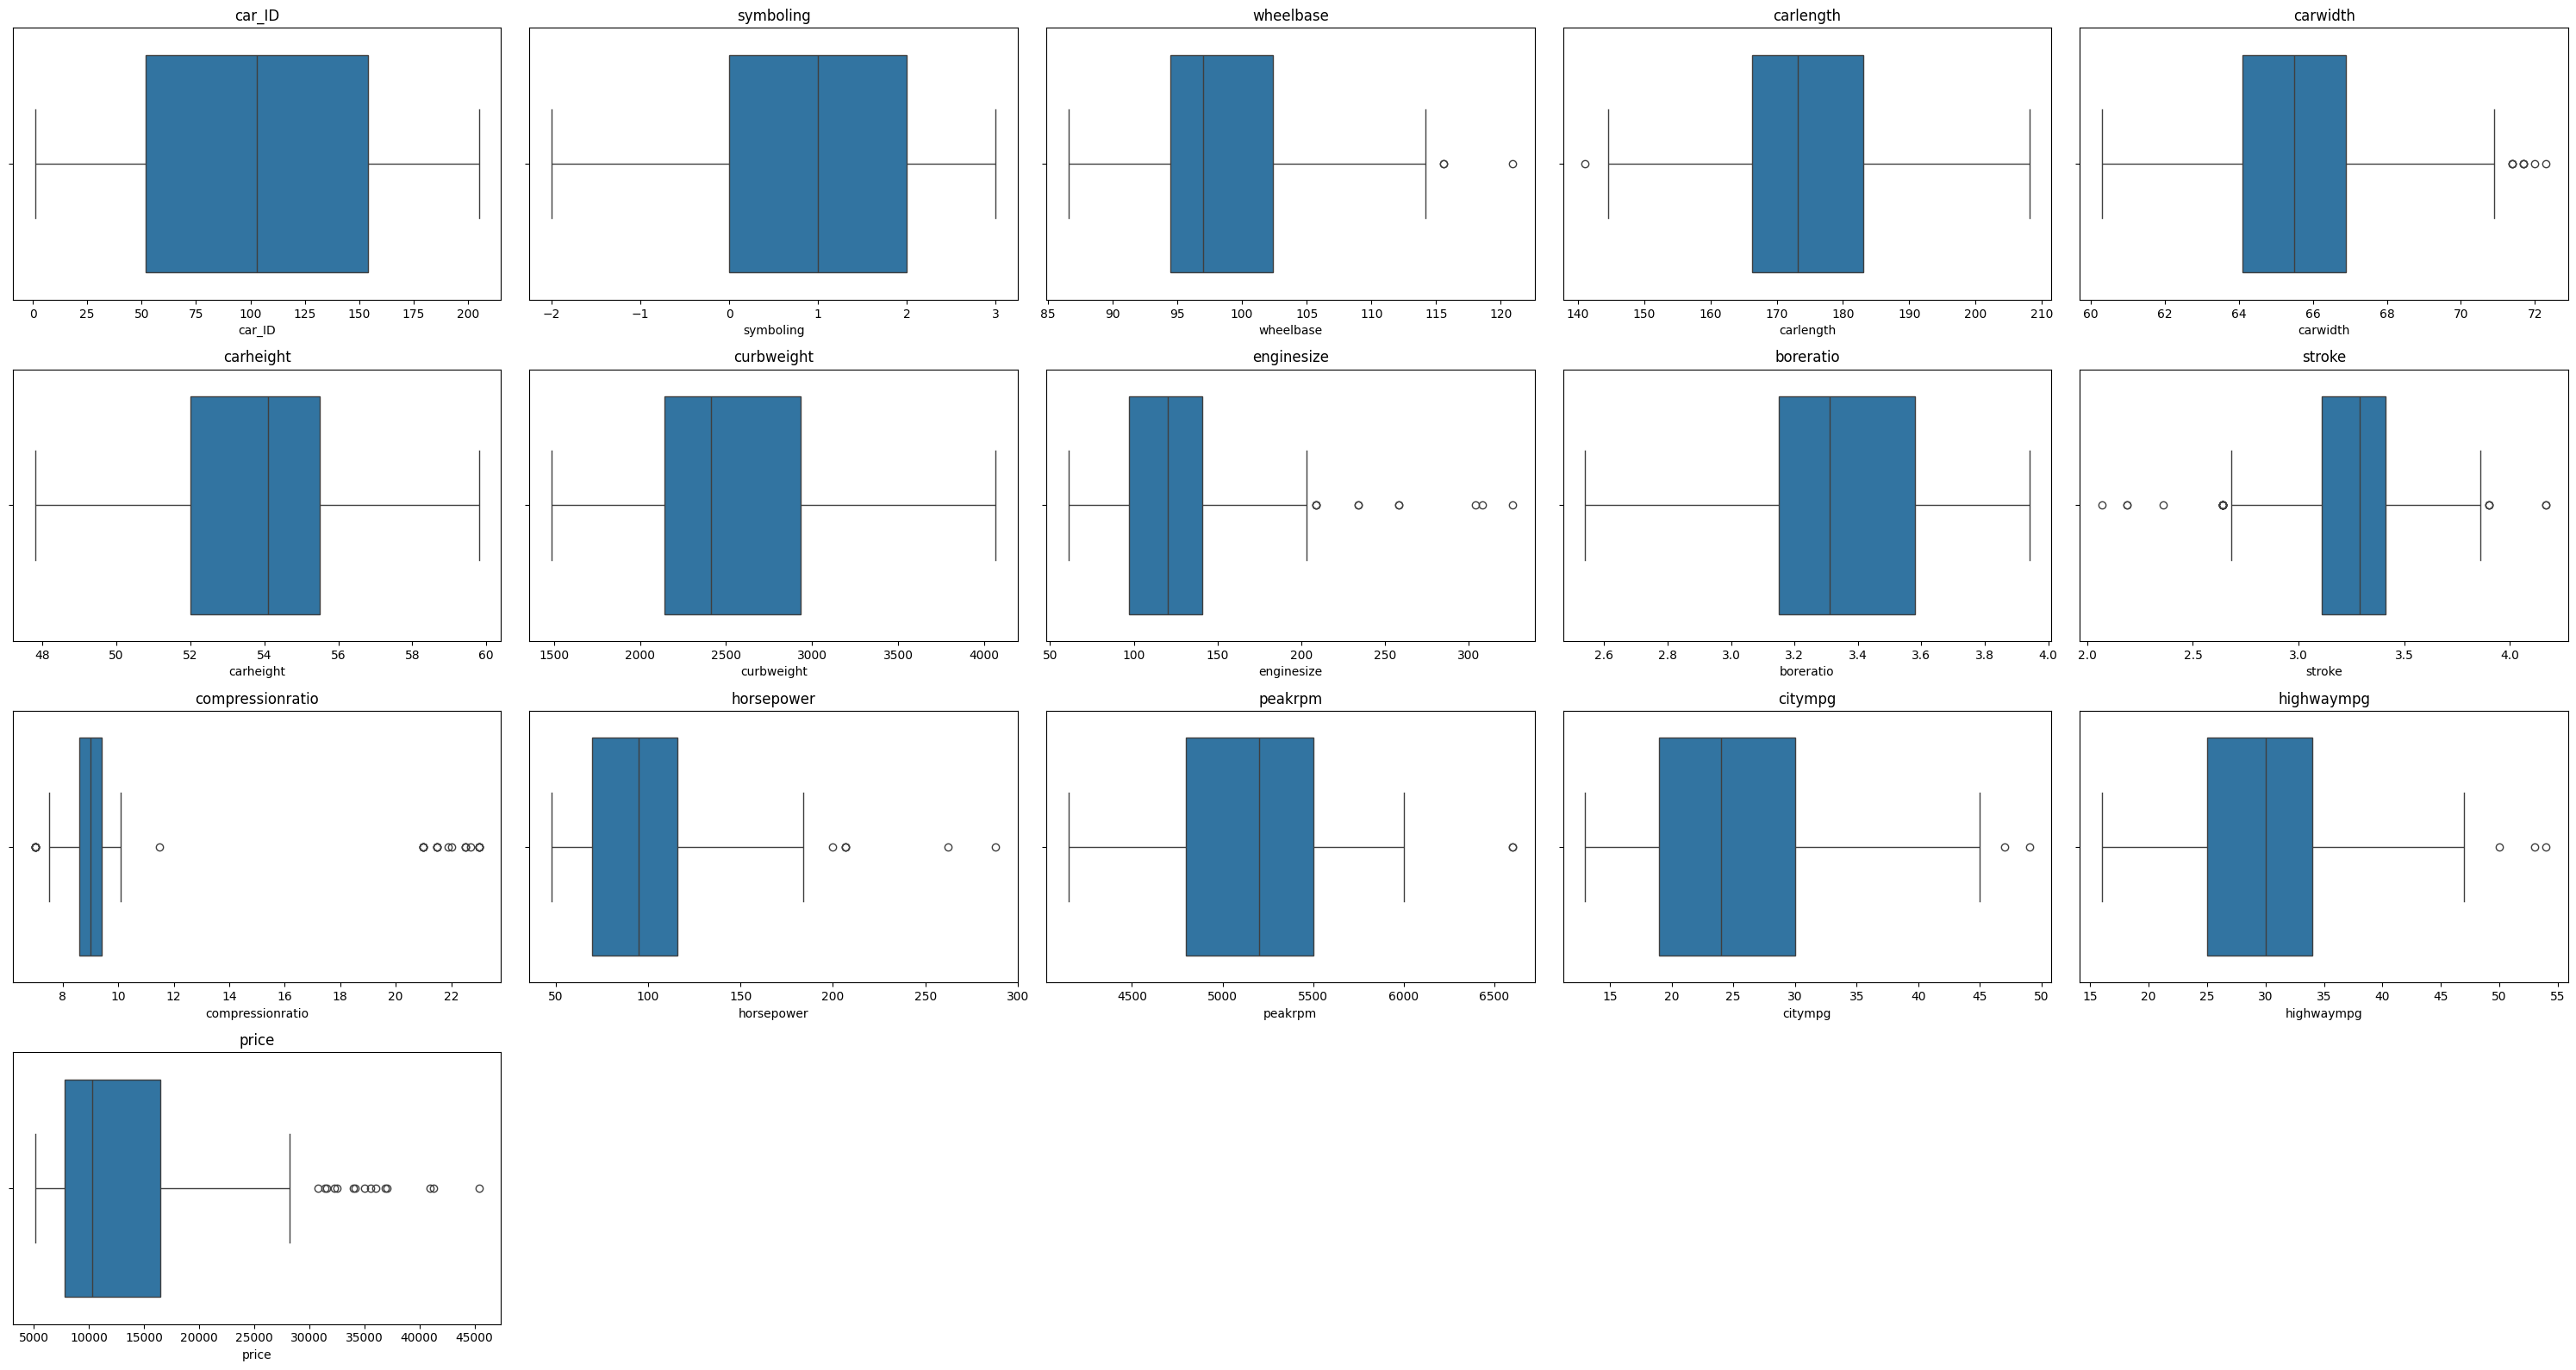

In [13]:
# Box Plot
plt.figure(figsize=(cols_per_row * 6, num_rows * 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows, cols_per_row, i + 1)
    sns.boxplot(x = df[col])
    plt.title(col, fontsize=12)

plt.tight_layout()
plt.show()

### Categorical Columns

In [14]:
num_cols = len(categorical_cols)
cols_per_row = 5
num_rows = int(np.ceil(num_cols / cols_per_row))

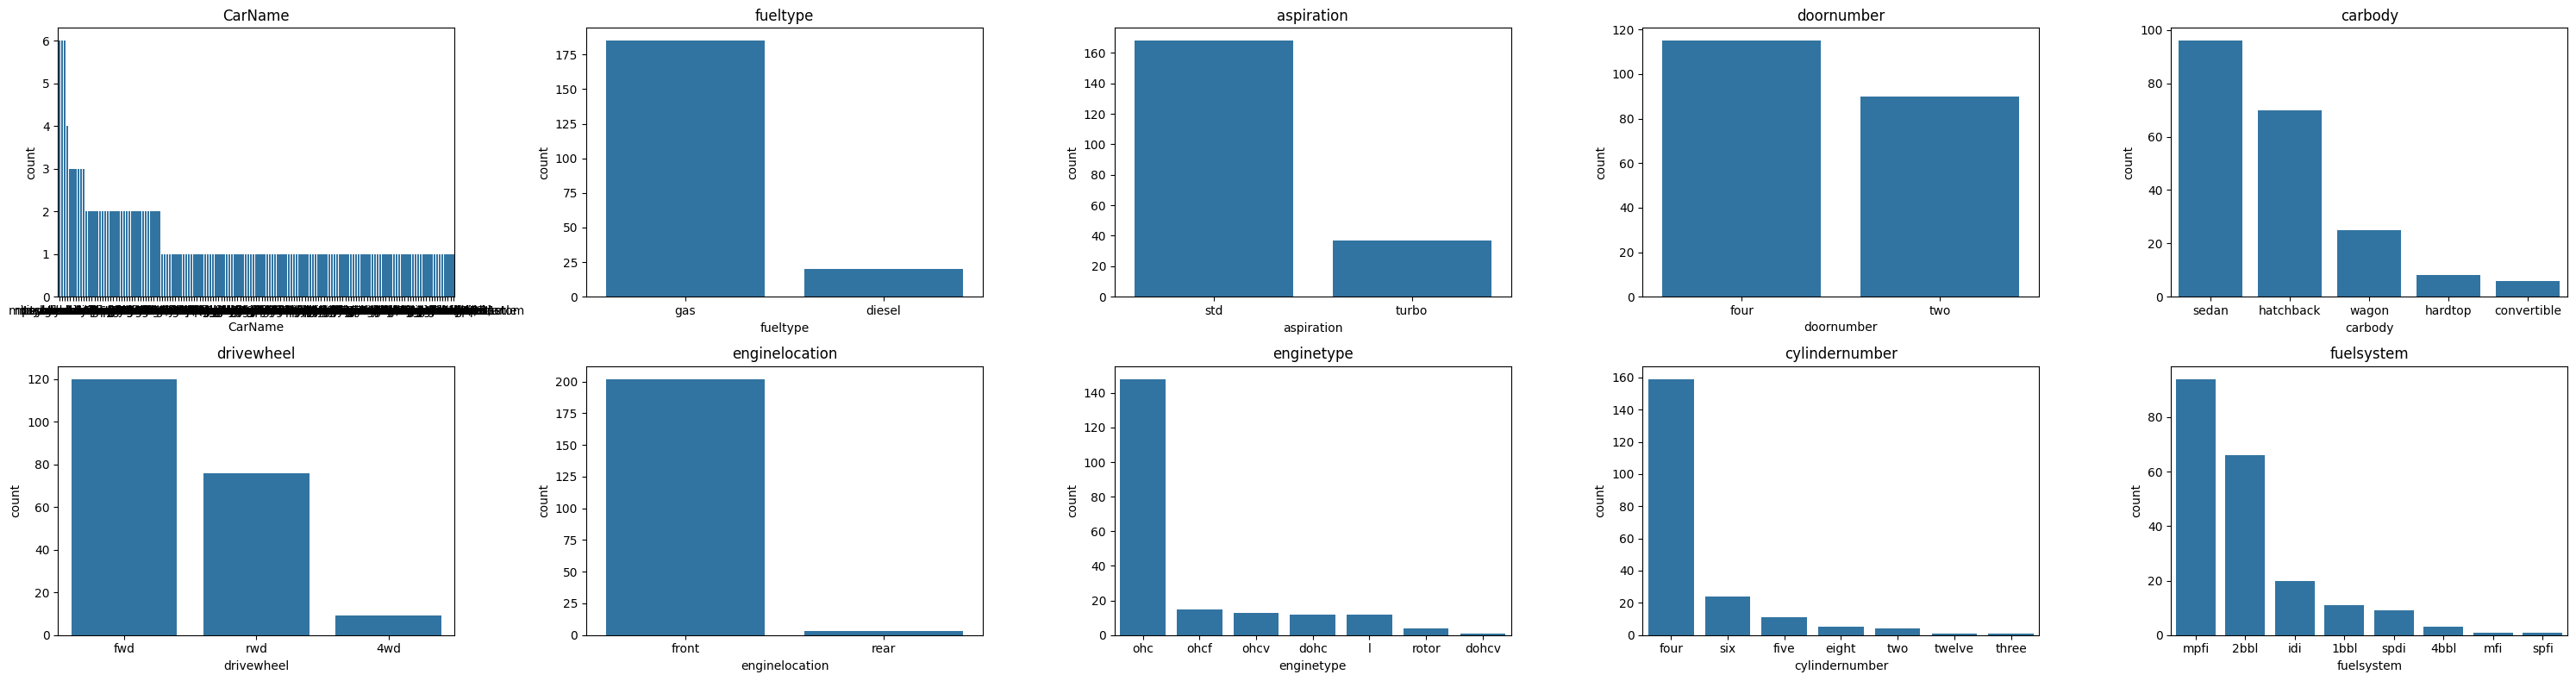

In [15]:
# Count Plot
plt.figure(figsize=(cols_per_row * 6, num_rows * 4))
for i, col in enumerate(categorical_cols):
    plt.subplot(num_rows, cols_per_row, i + 1)
    sns.countplot(x = df[col], order = df[col].value_counts().index)
    plt.title(col, fontsize=12)

plt.tight_layout()
plt.show()

In [16]:
# Value Counts
for col in categorical_cols:
    print(df[col].value_counts())
    print("-----------------------------------")

CarName
peugeot 504                 6
toyota corolla              6
toyota corona               6
subaru dl                   4
mitsubishi outlander        3
                           ..
volkswagen super beetle     1
volkswagen rabbit custom    1
volvo 245                   1
volvo diesel                1
volvo 246                   1
Name: count, Length: 147, dtype: int64
-----------------------------------
fueltype
gas       185
diesel     20
Name: count, dtype: int64
-----------------------------------
aspiration
std      168
turbo     37
Name: count, dtype: int64
-----------------------------------
doornumber
four    115
two      90
Name: count, dtype: int64
-----------------------------------
carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64
-----------------------------------
drivewheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64
-----------------------------------
enginelocation
front    20

### Insights
- Numerical variables such as `horsepower`, `engine-size`, and `curb-weight` show wide variation, indicating they might have strong influence on car prices.  
- Price distribution is **right-skewed**, suggesting that a few high-end cars significantly increase the mean price.  
- Categorical features like `fuel-type`, `body-style`, and `drive-wheels` display distinct groupings, and these categories could impact car price.  
- Overall, both numerical and categorical features provide useful signals for prediction.


#### Bivariate Analysis

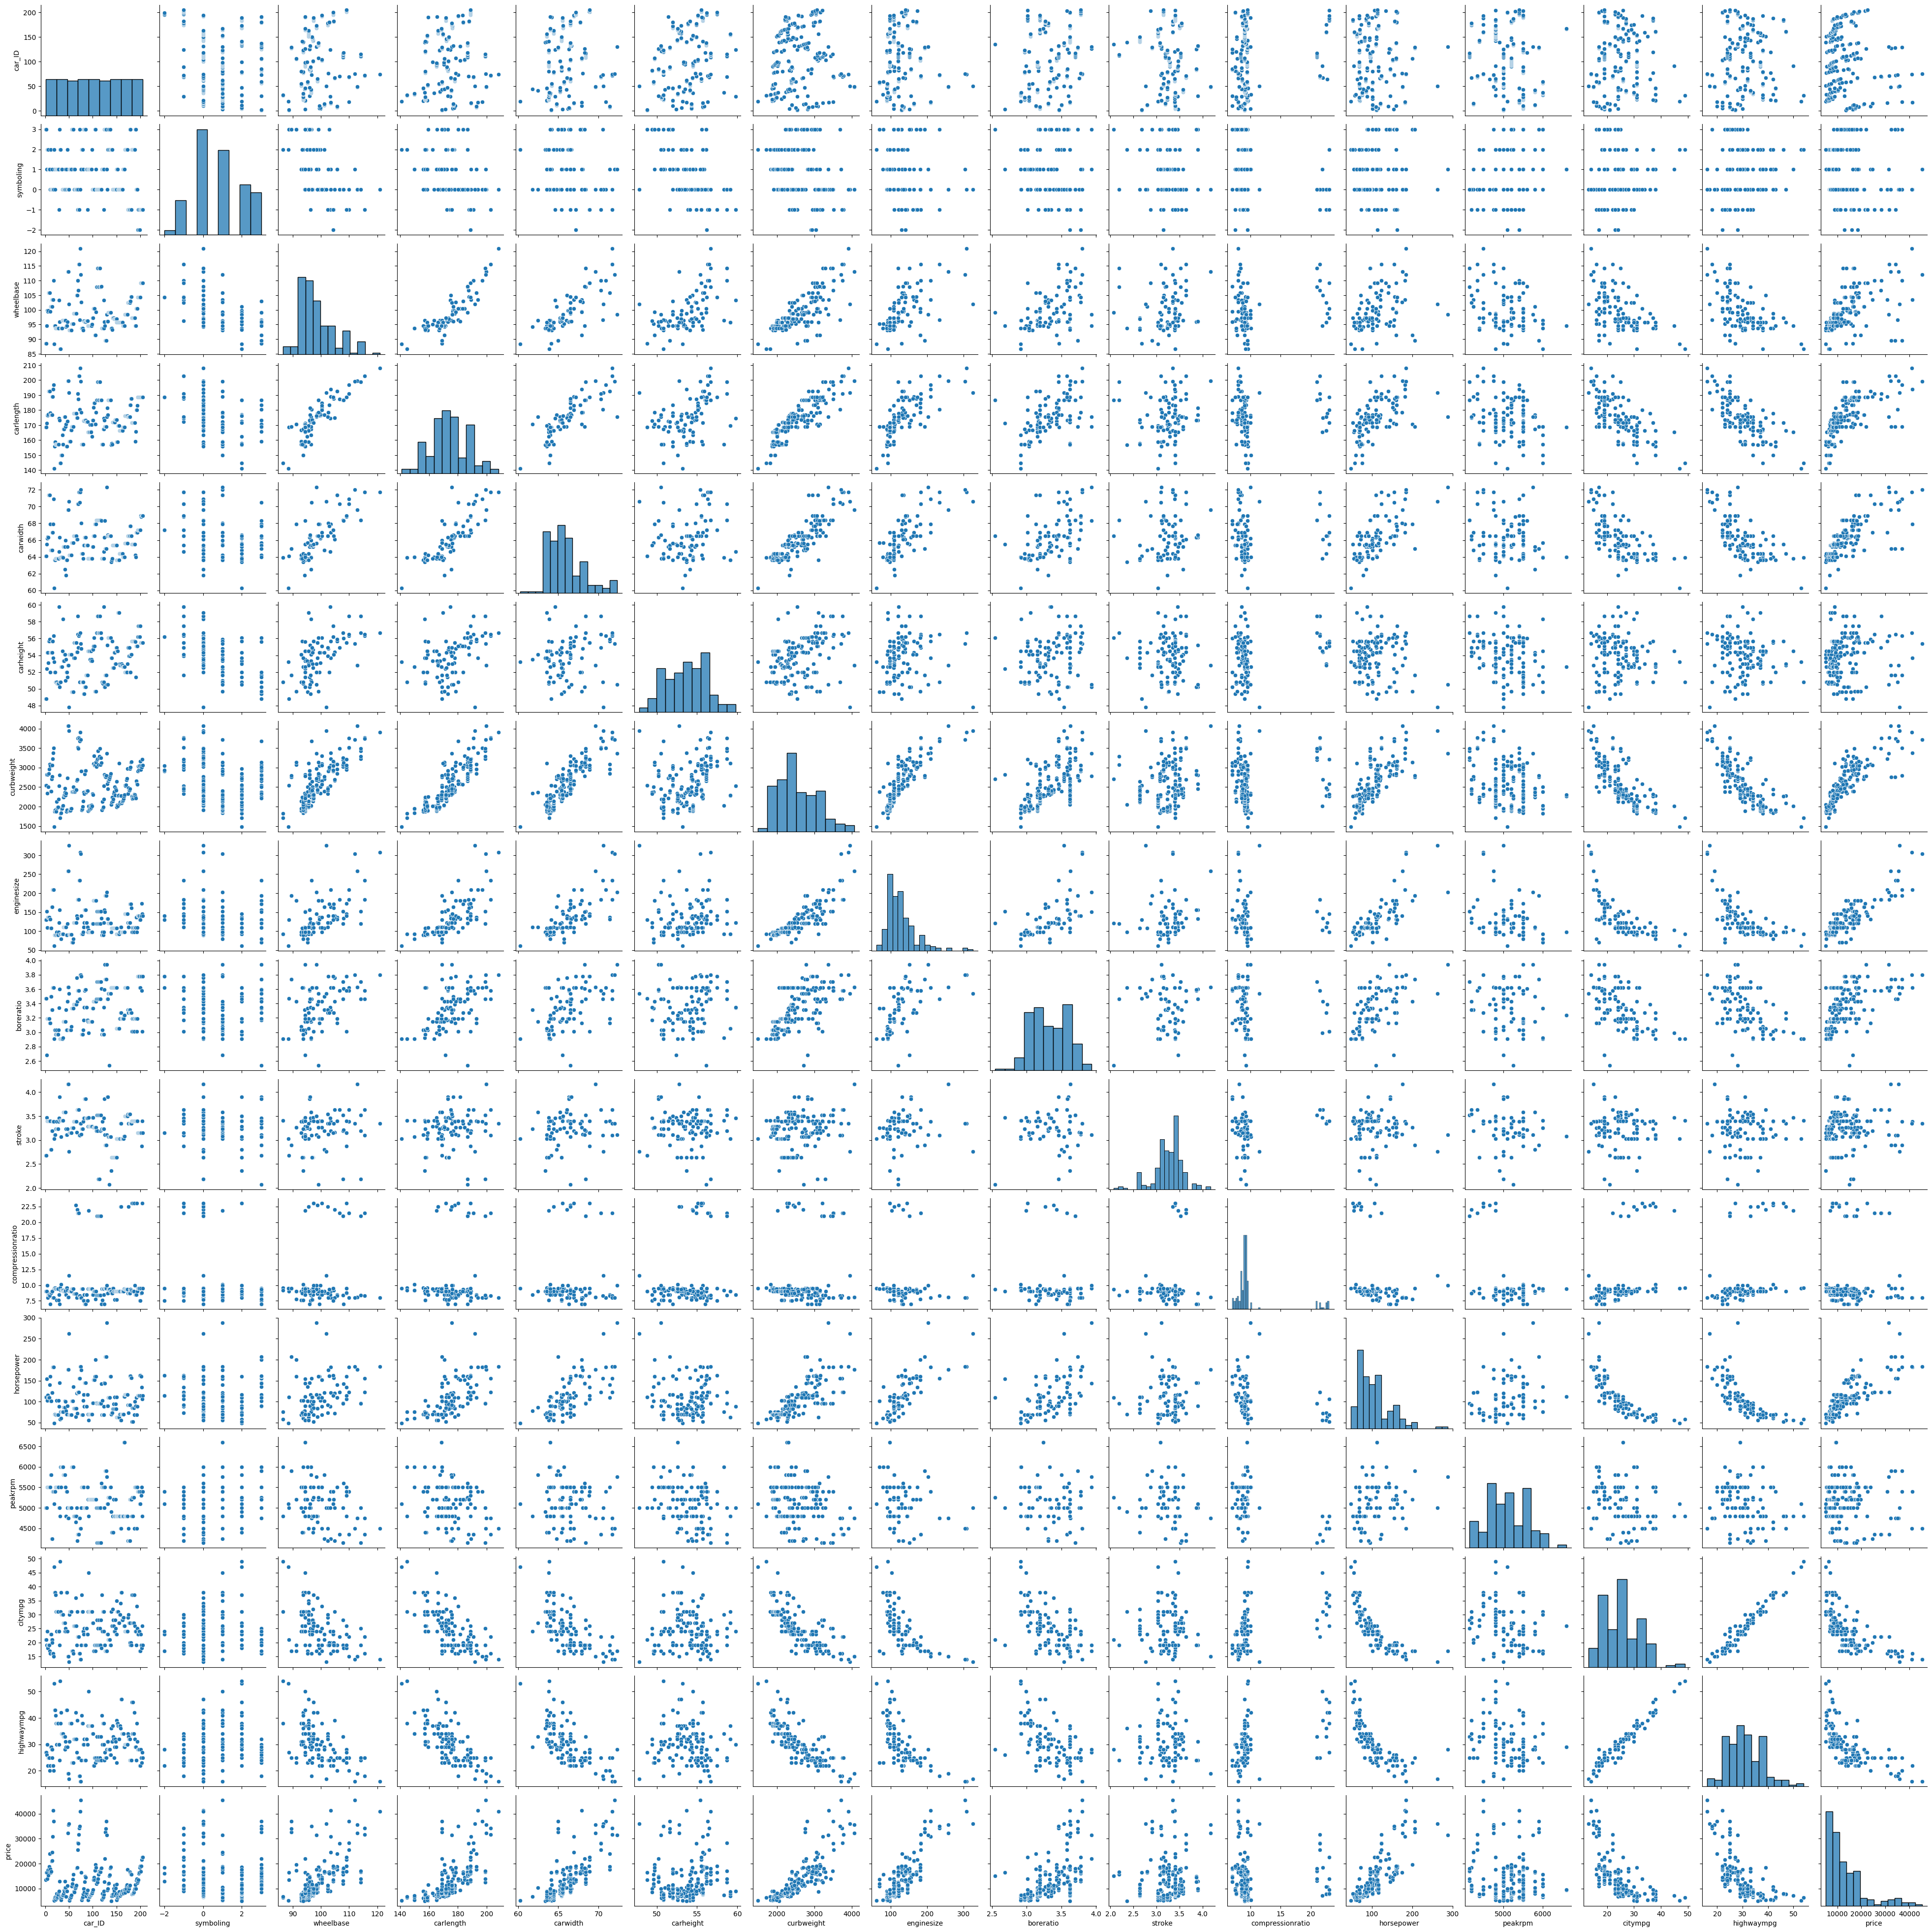

In [17]:
# Pairplot
sns.pairplot(df)

In [18]:
# Correlation for numerical data
num_corr = df.select_dtypes(exclude = ["object"]).corr()
num_corr

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
car_ID,1.000000,-0.151621,0.129729,0.170636,0.052387,0.255960,0.071962,-0.033930,0.260064,-0.160824,0.150276,-0.015006,-0.203789,0.015940,0.011255,-0.109093
symboling,-0.151621,1.000000,-0.531954,-0.357612,-0.232919,-0.541038,-0.227691,-0.105790,-0.130051,-0.008735,-0.178515,0.070873,0.273606,-0.035823,0.034606,-0.079978
wheelbase,0.129729,-0.531954,1.000000,0.874587,0.795144,0.589435,0.776386,0.569329,0.488750,0.160959,0.249786,0.353294,-0.360469,-0.470414,-0.544082,0.577816
carlength,0.170636,-0.357612,0.874587,1.000000,0.841118,0.491029,0.877728,0.683360,0.606454,0.129533,0.158414,0.552623,-0.287242,-0.670909,-0.704662,0.682920
carwidth,0.052387,-0.232919,0.795144,0.841118,1.000000,0.279210,0.867032,0.735433,0.559150,0.182942,0.181129,0.640732,-0.220012,-0.642704,-0.677218,0.759325
carheight,0.255960,-0.541038,0.589435,0.491029,0.279210,1.000000,0.295572,0.067149,0.171071,-0.055307,0.261214,-0.108802,-0.320411,-0.048640,-0.107358,0.119336
curbweight,0.071962,-0.227691,0.776386,0.877728,0.867032,0.295572,1.000000,0.850594,0.648480,0.168790,0.151362,0.750739,-0.266243,-0.757414,-0.797465,0.835305
enginesize,-0.033930,-0.105790,0.569329,0.683360,0.735433,0.067149,0.850594,1.000000,0.583774,0.203129,0.028971,0.809769,-0.244660,-0.653658,-0.677470,0.874145
boreratio,0.260064,-0.130051,0.488750,0.606454,0.559150,0.171071,0.648480,0.583774,1.000000,-0.055909,0.005197,0.573677,-0.254976,-0.584532,-0.587012,0.553173
stroke,-0.160824,-0.008735,0.160959,0.129533,0.182942,-0.055307,0.168790,0.203129,-0.055909,1.000000,0.186110,0.080940,-0.067964,-0.042145,-0.043931,0.079443


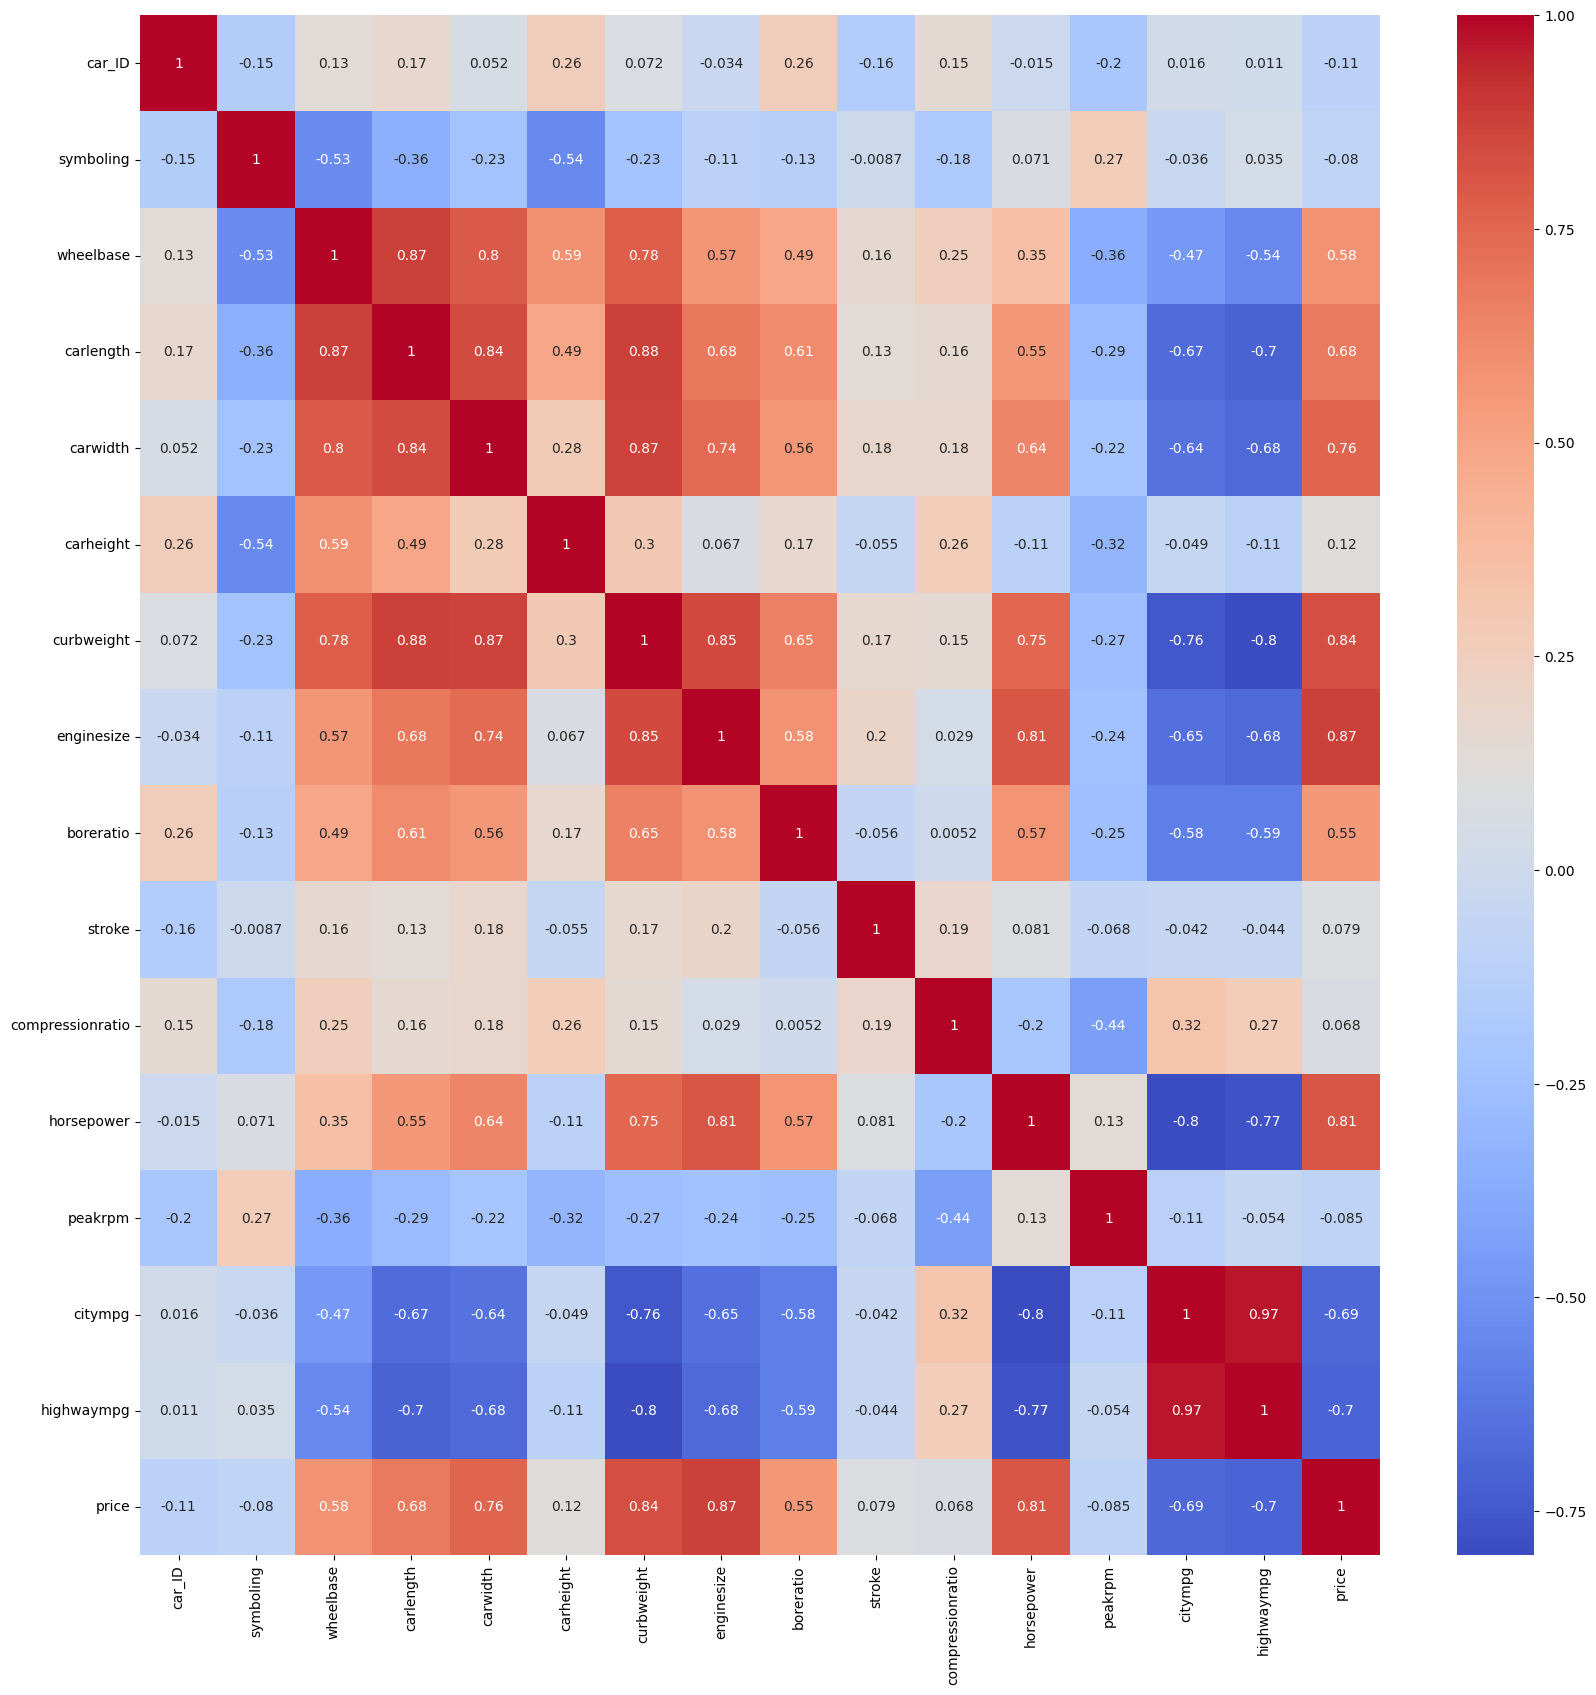

In [19]:
# Plot Heatmap
plt.figure(figsize = (20, 20))
sns.heatmap(num_corr, cmap='coolwarm', annot = True)
plt.show()

## Feature Engineering

In [20]:
# Dividing into X and y
X = df.drop(['price', 'car_ID', 'CarName'], axis=1) # Car_ID and Name have no significance
y = df['price']

In [21]:
# Identify column types
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [22]:
# Creating a Transformer
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop = 'first', sparse_output = False), categorical_cols)
    ]
)

In [23]:
# Creating preprocessing pipeline
pipeline = Pipeline(
    steps = [
        ('preprocess', preprocessor)
    ]
)

In [24]:
# Fitting and Transforming the data
X_processed = pipeline.fit_transform(X)

In [25]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size = 0.2, random_state = 42)

## Model Training

In [26]:
models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree' : DecisionTreeRegressor(random_state = 42),
    'Random Forest' : RandomForestRegressor(random_state = 42),
    'Gradient Boosting' : GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR()
}

In [27]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{name}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"R² Score: {r2:.2f}")
    print("---------------------------------")

Linear Regression
Mean Absolute Error: 2089.38
Mean Squared Error: 8482008.48
R² Score: 0.89
---------------------------------
Decision Tree
Mean Absolute Error: 1886.32
Mean Squared Error: 8300272.36
R² Score: 0.89
---------------------------------
Random Forest
Mean Absolute Error: 1262.02
Mean Squared Error: 3317859.52
R² Score: 0.96
---------------------------------
Gradient Boosting
Mean Absolute Error: 1678.36
Mean Squared Error: 5901221.27
R² Score: 0.93
---------------------------------
Support Vector Regressor
Mean Absolute Error: 5694.46
Mean Squared Error: 86812034.27
R² Score: -0.10
---------------------------------


## Conclusion
- There are no null values in the dataset, making the dataset good.
- The best model was Random Forest, with best r2 score of 0.96 and minimum mae.
- Since the dataset is small, we do not need to perform hyperparameter tuning.

- Final Model: Random Forest